# STEP 10. 공원 묶음 재정의 (후처리)

**배경**: Brooklyn 파일럿에서 N1abs·N1rel 묶음이 너무 넓었다. N1rel은 묶음 6개 모두 3 km를 넘었고(최대 12 km), N1abs도 일부 묶음이 53개 공원·5.6 km에 달했다. 원인은 세 가지다.
1. 파라미터 격자의 관대한 설정(θ = 90–180°, R = 3200 m)에서 공원 대부분이 하나의 연결요소로 **퍼콜레이션**되고, 이 설정들이 동반소속 비율을 끌어올린다.
2. Louvain resolution γ = 1 하나로는 묶음 스케일을 조절할 수 없다.
3. N1rel("거리 구간 하위 q")은 3 km 떨어진 쌍도 연결하므로 정의 자체가 넓은 묶음을 만든다.

**후처리 방안** (STEP 4–6의 저장 결과만 사용, 재계산 없음)
| 방안 | 내용 |
|---|---|
| **E. 묶음 범위 지표** | 모든 묶음의 공간 범위(대표점 간 최대 거리)와 네트워크 범위(구성원 간 최대 최단거리)를 계산 |
| **A. 그룹용 격자 분리** | 고립 판정(persistence)은 전체 격자를 그대로 쓴다. **묶음 합의에는 퍼콜레이션이 없는 설정만** 쓴다(최대 연결요소 < 공원의 50%) |
| **C. 가중 커뮤니티** | 엣지 가중치 $w_{ij} = \exp(-A_{ij}/45°)$: 직진에 가까운 강한 연결이 커뮤니티를 주도한다 |
| **B. 해상도 스케일** | Louvain γ ∈ {1, 2, 4} → 동네 스케일(γ=1) ↔ 블록 스케일(γ=4) 묶음을 함께 제시 |
| **D. N1 상호 k-최근접 각도 이웃 (N1knn)** | N1rel을 대체: 공원마다 각도 비용 하위 k개 공원을 고르고, **서로가 서로의 하위 k에 들 때만** 연결(k ∈ {3, 5}, 탐색 한계 R ∈ {1600, 3200}). 거리 임계값 없이도 희소한 그래프가 된다(동점은 최단거리로 구분) |

| **F. 도보 10분 제약** | 위 합의 묶음을 각각 공원 간 보행망 최단거리로 complete-linkage 분할(800 m에서 자름) → **묶음 안 모든 쌍이 서로 도보 10분 이내**. 거리는 관계의 정의가 아니라 안전 한계로만 쓴다 |

**출력**: `Data/derived/{AREA}/regroup/groups_{method}.parquet`, `group_extent_summary.csv`, `outputs/{AREA}/regroup/`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 연구 개요: 군집 구성 공원 주변 100 m = 상업 영역

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, pdist
from sklearn.metrics import adjusted_rand_score
warnings.filterwarnings("ignore", category=UserWarning)

GR_DIR = AREA_DIR / "graphs"
RG_DIR = AREA_DIR / "regroup"
RG_OUT = OUT_DIR / "regroup"
RG_DIR.mkdir(exist_ok=True)
RG_OUT.mkdir(exist_ok=True)

PERC_MAX = 0.5            # 그룹 합의에 쓰는 설정: 최대 연결요소 비율 < 0.5
GAMMAS = [1, 2, 4]        # Louvain 해상도 (클수록 작은 묶음)
ANG_SCALE = 45.0          # 가중치 exp(-A/45°)
KNN_K = [3, 5]
KNN_R = [1600, 3200]
DEF_CFG = f"d{int(ATTACH_BUFFER[PRIMARY])}_K{K_SOURCES}"

parks = gpd.read_parquet(NET_DIR / "parks.parquet")
cls = pd.read_parquet(GR_DIR / "classification.parquet")
settings = pd.read_csv(GR_DIR / "settings.csv")["setting"]
edges = pd.concat([pd.read_parquet(GR_DIR / f"edges_{d}.parquet") for d in ["D", "N1", "N2", "N3"]], ignore_index=True)
EDGE_GROUPS = dict(tuple(edges.groupby("setting")))
main_cls = cls[(cls.cap == AREA_CAP) & (cls.variant == PRIMARY)]
PIDS = sorted(main_cls.park_id.unique())
pid_set = set(PIDS)
PT = parks.loc[PIDS].geometry.representative_point()
print(f"{STUDY_AREA}: {len(PIDS)} parks")

# 대칭 공원 쌍 테이블 (각도 비용, 최단거리), E0 제외
pp = pd.read_parquet(AREA_DIR / f"pairs_{PRIMARY}.parquet")
pp = pp[(pp.cfg == DEF_CFG) & pp.i.isin(pid_set) & pp.j.isin(pid_set)]
lo, hi = np.minimum(pp.i, pp.j), np.maximum(pp.i, pp.j)
PAIRS = pp.assign(i=lo, j=hi).groupby(["i", "j"])[["D_net"] + [f"A_{r}" for r in N1_RADII]].min()
DNET = PAIRS["D_net"].dropna().to_dict()   # 도보 거리 제약용: E0·같은 공원 구간 쌍 포함 (3.2 km 밖은 없음 = 무한대)
e0 = pd.read_parquet(NET_DIR / "pairs_E0.parquet")
e0m = (e0[f"shared_{PRIMARY}"] > 0) | e0.touch
E0_KEYS = set(zip(e0.loc[e0m, "i"], e0.loc[e0m, "j"]))

def same_parent_pairs(parks):
    """같은 원래 공원(선형 공원 구간)끼리의 쌍: 공원 자신과의 관계이므로 E0처럼 제외."""
    pcs = parks[parks.get("is_piece", False) == True] if "is_piece" in parks else parks.iloc[:0]
    out = set()
    for _, ids in pcs.groupby("parent_id").groups.items():
        ids = sorted(ids)
        out |= {(a, b) for k, a in enumerate(ids) for b in ids[k + 1:]}
    return out


E0_KEYS |= same_parent_pairs(parks)
PAIRS = PAIRS[[k not in E0_KEYS for k in PAIRS.index]]
print(f"symmetric candidate pairs: {len(PAIRS):,}")

NYC: 2057 parks
symmetric candidate pairs: 100,884


## 10-1. 공통 함수: 커뮤니티, 합의 묶음, 묶음 범위

In [3]:
def communities(nodes, e, gamma=1.0, weight=None, seed=0):
    G = nx.Graph()
    G.add_nodes_from(nodes)
    if weight is None:
        G.add_edges_from(zip(e.i.values, e.j.values))
    else:
        G.add_weighted_edges_from(zip(e.i.values, e.j.values, weight))
    lab = pd.Series(-1, index=nodes)
    if G.number_of_edges():
        cms = nx.community.louvain_communities(G, weight="weight" if weight is not None else None,
                                               resolution=gamma, seed=seed)
        for k, cm in enumerate(cms):
            if len(cm) > 1:
                lab[list(cm)] = k
    deg = pd.Series(dict(G.degree())).reindex(nodes)
    return lab, deg


def consensus(label_list, pids, cut=0.5):
    """설정별 커뮤니티 라벨 목록 → 평균 연결 합의 묶음 (-1 = 묶음 없음)."""
    n = len(pids)
    M = np.zeros((n, n), dtype=np.float32)
    for lab in label_list:
        l = lab.reindex(pids).fillna(-1).values
        M += (l[:, None] == l[None, :]) & (l[:, None] >= 0)
    M /= max(len(label_list), 1)
    np.fill_diagonal(M, 1.0)
    D = 1.0 - M
    np.fill_diagonal(D, 0)
    lab = fcluster(linkage(squareform(D, checks=False), method="average"), t=cut, criterion="distance")
    s = pd.Series(lab, index=pids)
    size = s.map(s.value_counts())
    return s.where(size >= 2, -1), M


def walk_dist(a, b):
    """공원 쌍 보행망 최단거리 (m). 3.2 km 탐색 밖이면 무한대."""
    if a == b:
        return 0.0
    return DNET.get((a, b) if a < b else (b, a), np.inf)


def group_extent(labels):
    """묶음별 크기, 공간 범위(km), 네트워크 범위(km, 구성원 쌍 최단거리 최대; 3.2 km 밖 쌍은 미측정)."""
    rows = []
    for gid, members in labels[labels >= 0].groupby(labels).groups.items():
        m = list(members)
        xy = np.c_[PT[m].x, PT[m].y]
        sub = PAIRS.loc[PAIRS.index.isin([(a, b) for ai, a in enumerate(sorted(m)) for b in sorted(m)[ai + 1:]]), "D_net"]
        n_pairs = len(m) * (len(m) - 1) / 2
        mw = max(walk_dist(a, b) for k, a in enumerate(m) for b in m[k + 1:])
        rows.append({"group": gid, "n": len(m), "extent_km": pdist(xy).max() / 1000, "max_walk_m": mw,
                     "net_extent_km": sub.max() / 1000 if len(sub) else np.nan,
                     "pairs_within_3200": len(sub) / n_pairs, "acres": parks.loc[m, "acres"].sum()})
    return pd.DataFrame(rows)


def summarize(name, labels, iso=None):
    ex = group_extent(labels)
    return {"method": name, "groups": len(ex), "parks_in_groups": int(ex.n.sum()) if len(ex) else 0,
            "size_median": ex.n.median() if len(ex) else 0, "size_max": ex.n.max() if len(ex) else 0,
            "extent_median_km": ex.extent_km.median() if len(ex) else 0,
            "extent_p90_km": ex.extent_km.quantile(0.9) if len(ex) else 0,
            "extent_max_km": ex.extent_km.max() if len(ex) else 0,
            "groups_over_3km": int((ex.extent_km > 3).sum()) if len(ex) else 0,
            "max_walk_median_m": float(np.median(np.minimum(ex.max_walk_m, 1e5))) if len(ex) else 0,
            "groups_over_walk_limit": int((ex.max_walk_m > WALK_LIMIT).sum()) if len(ex) else 0,
            "robust_isolated": int((iso >= 0.8).sum()) if iso is not None else np.nan}

## 10-2. 기준선: STEP 7의 원래 묶음 범위

In [4]:
summary_rows = []
ORIG = {}
for d in ["D", "N1abs", "N1rel", "N2", "N3"]:
    g = pd.read_parquet(AREA_DIR / f"robust_groups_{d}.parquet").reindex(PIDS)
    ORIG[d] = g
    summary_rows.append(summarize(f"{d} (original)", g.group_g50, g.iso))
pd.DataFrame(summary_rows).round(2)

,method,groups,parks_in_groups,size_median,size_max,extent_median_km,extent_p90_km,extent_max_km,groups_over_3km,max_walk_median_m,groups_over_walk_limit,robust_isolated
0,D (original),213,1692,3.0,76,0.52,2.05,4.89,8,433.56,74,76
1,N1abs (original),186,1577,3.0,100,0.95,3.02,5.59,19,914.13,102,132
2,N1rel (original),42,1812,4.5,220,1.92,10.71,13.75,17,2014.69,36,226
3,N2 (original),193,1504,3.0,78,0.78,2.36,5.29,11,671.52,78,365
4,N3 (original),63,157,2.0,8,0.78,1.52,2.33,0,696.11,26,1619


## 10-3. 방안 A: 퍼콜레이션 없는 설정만 그룹 합의에 사용 (N1abs)
설정별 최대 연결요소 비율. 이 값이 0.5 이상이면 공원 절반 이상이 한 연결요소로 묶이므로 묶음 구분이 무의미하다. 그런 설정은 **묶음 합의에서만** 제외하고, 고립 판정(IsolationPersistence)에는 그대로 쓴다.

**보로 단위 판정**: 보로들이 물로 나뉘어 있어 시 전체 비율은 퍼콜레이션을 가린다. 예를 들어 맨해튼 공원의 80%가 한 덩어리여도 시 전체 비율은 20%에 그친다. 그래서 보로마다 "그 보로 공원 중 최대 연결요소에 속한 비율"을 구하고, 그 **최댓값**이 0.5 미만인 설정만 쓴다.

In [5]:
def _largest_share(g):
    c = g.loc[g.comp >= 0].groupby("comp").size()
    return (c.max() if len(c) else 1) / len(g)


def percolation(defn):
    """정의의 설정별 퍼콜레이션: 보로마다 최대 연결요소 비율 → 최댓값 < PERC_MAX 이면 묶음 합의에 사용."""
    c = main_cls[main_cls.definition == defn]
    if defn in ("N1abs", "D"):
        c = c[c.setting.str.contains(f"\\|{DEF_CFG}\\|")]
    c = c.assign(borough=c.park_id.map(parks.borough))
    bshare = c.groupby(["setting", "borough"])[["comp"]].apply(_largest_share).unstack()
    out = pd.DataFrame({"largest_share_citywide": c.groupby("setting").comp_size.max() / c.groupby("setting").size()})
    out = out.join(bshare.add_prefix("share_"))
    out["largest_share"] = bshare.max(axis=1)
    out["use_for_groups"] = out.largest_share < PERC_MAX
    if not out.use_for_groups.any():        # 모든 설정이 퍼콜레이션되면 전체 사용
        out["use_for_groups"] = True
    return out


PERC_TABLES = {d: percolation(d) for d in ["D", "N1abs", "N2", "N3"]}
for d, t in PERC_TABLES.items():
    t.to_csv(RG_DIR / f"percolation_{d}.csv")
PERC_TABLES["N1abs"].to_csv(RG_DIR / "n1_percolation.csv")
KEEP_BY = {d: t.index[t.use_for_groups].tolist() for d, t in PERC_TABLES.items()}
KEEP = KEEP_BY["N1abs"]
print({d: f"{len(k)}/{len(PERC_TABLES[d])}" for d, k in KEEP_BY.items()}, "settings kept for grouping")
perc = PERC_TABLES["N1abs"]
perc.sort_values("largest_share").round(3)

{'D': '1/3', 'N1abs': '9/24', 'N2': '5/9', 'N3': '16/16'} settings kept for grouping


,largest_share_citywide,share_B,share_M,share_Q,share_R,share_X,largest_share,use_for_groups
setting,,,,,,,,
N1abs|C|d20_K8|R800|th15|rob,0.060,0.111,0.282,0.029,0.022,0.060,0.282,True
N1abs|C|d20_K8|R1600|th15|rob,0.068,0.224,0.289,0.063,0.022,0.120,0.289,True
N1abs|C|d20_K8|R3200|th15|rob,0.069,0.227,0.289,0.063,0.022,0.120,0.289,True
N1abs|C|d20_K8|R800|th15|best,0.062,0.113,0.292,0.029,0.030,0.063,0.292,True
N1abs|C|d20_K8|R1600|th15|best,0.070,0.229,0.305,0.063,0.030,0.125,0.305,True
N1abs|C|d20_K8|R3200|th15|best,0.070,0.232,0.305,0.063,0.030,0.125,0.305,True
N1abs|C|d20_K8|R800|th45|rob,0.074,0.209,0.349,0.063,0.022,0.091,0.349,True
N1abs|C|d20_K8|R800|th45|best,0.090,0.216,0.358,0.063,0.030,0.097,0.358,True
N1abs|C|d20_K8|R800|th90|rob,0.165,0.303,0.367,0.092,0.030,0.465,0.465,True


## 10-4. 방안 A + C + B: 비퍼콜레이션 설정 × 가중 Louvain × 해상도 γ
가중치는 해당 설정의 R에서의 최소 각도 비용 $A_{ij}(R)$로 만든다: $w = \exp(-A/45°)$. 직진(0°)이면 1, 한 번 꺾음(90°)이면 0.14.

In [6]:
def setting_weights(setting, e):
    R = int(setting.split("|")[3][1:])
    key = list(zip(np.minimum(e.i, e.j), np.maximum(e.i, e.j)))
    A = PAIRS[f"A_{R}"].reindex(key).fillna(0).values
    return np.exp(-A / ANG_SCALE)


N1_GROUPS = {}
for gamma in GAMMAS:
    labs = []
    for s in KEEP:
        e = EDGE_GROUPS.get(s, edges.iloc[:0])
        e = e[e.i.isin(pid_set) & e.j.isin(pid_set)]
        lab, _ = communities(PIDS, e, gamma=gamma, weight=setting_weights(s, e))
        labs.append(lab)
    grp, _ = consensus(labs, PIDS, 0.5)
    N1_GROUPS[gamma] = grp
    summary_rows.append(summarize(f"N1abs A+C γ={gamma}", grp, ORIG["N1abs"].iso))
pd.DataFrame(summary_rows).round(2)

,method,groups,parks_in_groups,size_median,size_max,extent_median_km,extent_p90_km,extent_max_km,groups_over_3km,max_walk_median_m,groups_over_walk_limit,robust_isolated
0,D (original),213,1692,3.0,76,0.52,2.05,4.89,8,433.56,74,76
1,N1abs (original),186,1577,3.0,100,0.95,3.02,5.59,19,914.13,102,132
2,N1rel (original),42,1812,4.5,220,1.92,10.71,13.75,17,2014.69,36,226
3,N2 (original),193,1504,3.0,78,0.78,2.36,5.29,11,671.52,78,365
4,N3 (original),63,157,2.0,8,0.78,1.52,2.33,0,696.11,26,1619
5,N1abs A+C γ=1,210,1209,3.0,86,0.57,1.63,4.43,5,459.70,55,132
6,N1abs A+C γ=2,217,1208,3.0,41,0.58,1.75,3.82,3,467.04,61,132
7,N1abs A+C γ=4,227,1208,3.0,30,0.61,1.81,3.25,1,492.55,69,132


## 10-4b. 같은 절차를 D·N2·N3에도 적용 (정의 간 공정 비교)
연구 개요 RQ3는 정의 간 일관성을 비교한다. 그래서 묶음을 만드는 방식을 통일한다.
1. 보로 단위 퍼콜레이션이 없는 설정만 사용(없으면 전체)
2. 설정별 Louvain(γ = `MAIN_GAMMA`)
3. 합의 ≥ 0.5
4. 10-8의 도보 10분 지름 분할

N1만 각도 가중치 exp(−A/45°)를 쓰고, 나머지는 가중치 없이 쓴다.

In [7]:
UNI_GROUPS = {}
for d in ["D", "N2", "N3"]:
    labs = []
    for s_ in KEEP_BY[d]:
        e = EDGE_GROUPS.get(s_, edges.iloc[:0])
        e = e[e.i.isin(pid_set) & e.j.isin(pid_set)]
        lab, _ = communities(PIDS, e, gamma=MAIN_GAMMA)
        labs.append(lab)
    UNI_GROUPS[d], _ = consensus(labs, PIDS, 0.5)
    summary_rows.append(summarize(f"{d} unified (γ={MAIN_GAMMA})", UNI_GROUPS[d], ORIG[d].iso))
pd.DataFrame(summary_rows).round(2)

,method,groups,parks_in_groups,size_median,size_max,extent_median_km,extent_p90_km,extent_max_km,groups_over_3km,max_walk_median_m,groups_over_walk_limit,robust_isolated
0,D (original),213,1692,3.0,76,0.52,2.05,4.89,8,433.56,74,76
1,N1abs (original),186,1577,3.0,100,0.95,3.02,5.59,19,914.13,102,132
2,N1rel (original),42,1812,4.5,220,1.92,10.71,13.75,17,2014.69,36,226
3,N2 (original),193,1504,3.0,78,0.78,2.36,5.29,11,671.52,78,365
4,N3 (original),63,157,2.0,8,0.78,1.52,2.33,0,696.11,26,1619
5,N1abs A+C γ=1,210,1209,3.0,86,0.57,1.63,4.43,5,459.70,55,132
6,N1abs A+C γ=2,217,1208,3.0,41,0.58,1.75,3.82,3,467.04,61,132
7,N1abs A+C γ=4,227,1208,3.0,30,0.61,1.81,3.25,1,492.55,69,132
8,D unified (γ=2),281,1282,3.0,29,0.31,1.07,3.56,1,193.90,44,76
9,N2 unified (γ=2),231,1224,3.0,32,0.44,1.41,2.64,0,317.84,57,365


## 10-5. 방안 D: N1 상호 k-최근접 각도 이웃 (N1knn, N1rel 대체)
- 공원 i의 후보 = simplest path 길이 ≤ R로 닿는 공원(E0 제외)
- 각도 비용 $A_{ij}(R)$ 오름차순(동점이면 최단거리 순) 상위 k개 = i의 이웃
- **i와 j가 서로의 상위 k 안에 들 때만** 연결 → 공원당 엣지 최대 k개, 희소 그래프
- 4개 설정(k × R)에서 고립 persistence와 Louvain(γ=1, 가중) 합의 묶음

In [8]:
def mutual_knn(k, R):
    col = f"A_{R}"
    df = PAIRS[PAIRS[col].notna()].reset_index()
    both = pd.concat([df[["i", "j", col, "D_net"]],
                      df.rename(columns={"i": "j", "j": "i"})[["i", "j", col, "D_net"]]])
    both = both.sort_values(["i", col, "D_net"])
    both["rank"] = both.groupby("i").cumcount()
    top = both[both["rank"] < k]
    s = set(zip(top.i, top.j))
    mutual = [(a, b) for a, b in s if a < b and (b, a) in s]
    e = pd.DataFrame(mutual, columns=["i", "j"])
    e["A"] = PAIRS[col].reindex(list(zip(e.i, e.j))).values
    return e


KNN_LABS, KNN_ISO = [], []
knn_edges = []
for k in KNN_K:
    for R in KNN_R:
        e = mutual_knn(k, R)
        e["setting"] = f"N1knn|{PRIMARY}|{DEF_CFG}|k{k}|R{R}"
        knn_edges.append(e)
        lab, deg = communities(PIDS, e, gamma=1.0, weight=np.exp(-e.A.values / ANG_SCALE))
        KNN_LABS.append(lab)
        KNN_ISO.append((deg == 0).astype(float))
        print(f"k={k} R={R}: {len(e):,} mutual edges, isolated {int((deg == 0).sum())}")
pd.concat(knn_edges).to_parquet(RG_DIR / "edges_N1knn.parquet")
knn_iso = pd.concat(KNN_ISO, axis=1).mean(axis=1)
KNN_GROUPS, _ = consensus(KNN_LABS, PIDS, 0.5)
summary_rows.append(summarize("N1knn (mutual k-NN angular)", KNN_GROUPS, knn_iso))
SUMMARY = pd.DataFrame(summary_rows)
SUMMARY.to_csv(RG_DIR / "group_extent_summary.csv", index=False)
SUMMARY.round(2)

k=3 R=1600: 1,846 mutual edges, isolated 302
k=3 R=3200: 1,775 mutual edges, isolated 326


k=5 R=1600: 3,274 mutual edges, isolated 132
k=5 R=3200: 3,138 mutual edges, isolated 165


,method,groups,parks_in_groups,size_median,size_max,extent_median_km,extent_p90_km,extent_max_km,groups_over_3km,max_walk_median_m,groups_over_walk_limit,robust_isolated
0,D (original),213,1692,3.0,76,0.52,2.05,4.89,8,433.56,74,76
1,N1abs (original),186,1577,3.0,100,0.95,3.02,5.59,19,914.13,102,132
2,N1rel (original),42,1812,4.5,220,1.92,10.71,13.75,17,2014.69,36,226
3,N2 (original),193,1504,3.0,78,0.78,2.36,5.29,11,671.52,78,365
4,N3 (original),63,157,2.0,8,0.78,1.52,2.33,0,696.11,26,1619
5,N1abs A+C γ=1,210,1209,3.0,86,0.57,1.63,4.43,5,459.70,55,132
6,N1abs A+C γ=2,217,1208,3.0,41,0.58,1.75,3.82,3,467.04,61,132
7,N1abs A+C γ=4,227,1208,3.0,30,0.61,1.81,3.25,1,492.55,69,132
8,D unified (γ=2),281,1282,3.0,29,0.31,1.07,3.56,1,193.90,44,76
9,N2 unified (γ=2),231,1224,3.0,32,0.44,1.41,2.64,0,317.84,57,365


## 10-6. 비교: 원래 묶음과의 일치도, 근접성과의 관계
- `ARI_vs_original_N1abs`: 원래 N1abs 묶음과의 일치도
- `mean_D_net_within`: 묶음 내부 공원 쌍의 평균 최단거리(작을수록 근거리 묶음)
- `share_within_pairs_A≤45`: 묶음 내부 쌍 중 직진에 가까운(각도 비용 45° 이하) 쌍의 비율 → 묶음이 실제로 few-turn 관계로 묶였는지 확인

In [9]:
def with_singletons(s):
    s = s.copy()
    m = s < 0
    s[m] = -np.arange(1, m.sum() + 1)
    return s


def within_stats(labels):
    rows = []
    for gid, members in labels[labels >= 0].groupby(labels).groups.items():
        m = sorted(members)
        keys = [(a, b) for ai, a in enumerate(m) for b in m[ai + 1:]]
        sub = PAIRS.reindex(keys)
        rows.append((sub.D_net.mean(), (sub["A_3200"] <= 45).mean()))
    a = np.array(rows) if rows else np.zeros((1, 2))
    return np.nanmean(a[:, 0]), np.nanmean(a[:, 1])


cmp_rows = []
CANDIDATES = {"N1abs (original)": ORIG["N1abs"].group_g50, "N1rel (original)": ORIG["N1rel"].group_g50,
              **{f"N1abs A+C γ={g}": N1_GROUPS[g] for g in GAMMAS}, "N1knn": KNN_GROUPS}
for name, lab in CANDIDATES.items():
    dn, a45 = within_stats(lab)
    cmp_rows.append({"method": name,
                     "ARI_vs_original_N1abs": adjusted_rand_score(with_singletons(ORIG["N1abs"].group_g50), with_singletons(lab)),
                     "mean_D_net_within_m": dn, "share_within_pairs_A≤45": a45})
pd.DataFrame(cmp_rows).round(3)

,method,ARI_vs_original_N1abs,mean_D_net_within_m,share_within_pairs_A≤45
0,N1abs (original),1.000,710.240,0.569
1,N1rel (original),0.263,1275.716,0.237
2,N1abs A+C γ=1,0.675,406.183,0.773
3,N1abs A+C γ=2,0.542,416.528,0.759
4,N1abs A+C γ=4,0.430,416.538,0.751
5,N1knn,0.574,1074.885,0.223


## 10-7. 지도: 원래 N1abs vs 재정의 묶음

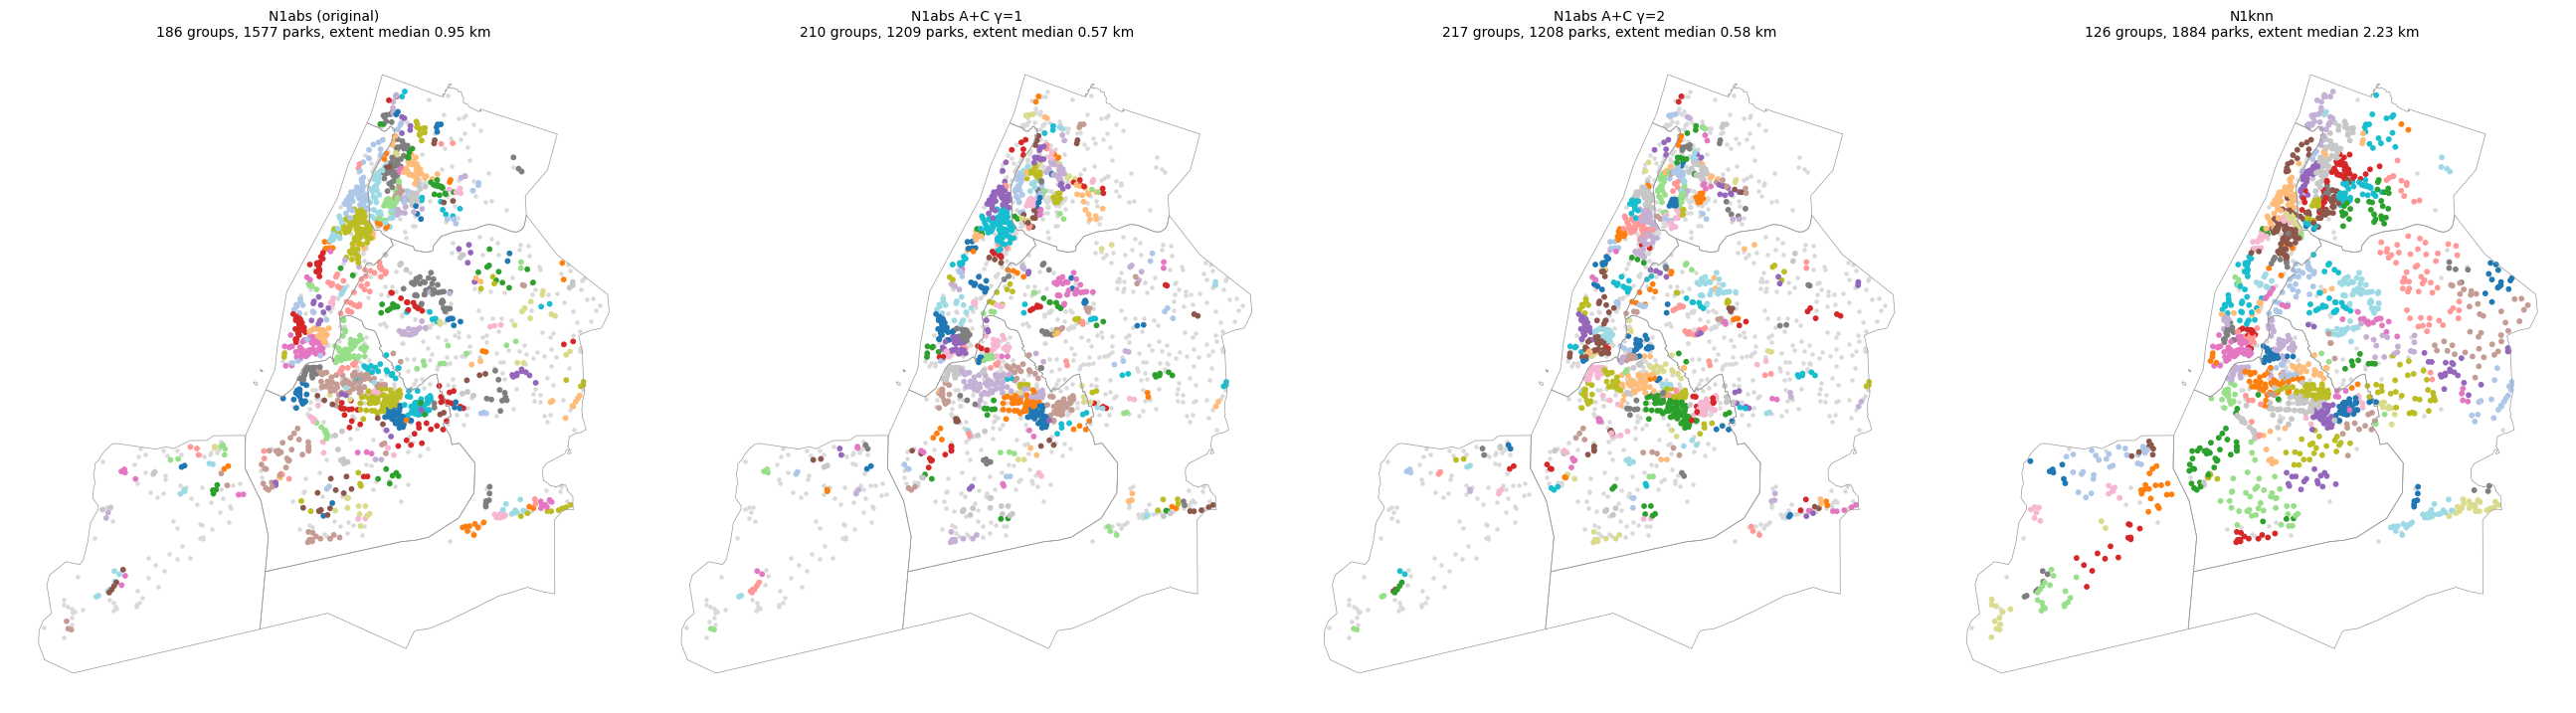

In [10]:
def group_colors(labels, seed=0):
    ids = sorted(labels[labels >= 0].unique())
    cmap = plt.get_cmap("tab20")
    return {gid: mcolors.to_hex(cmap(k % 20)) for k, gid in enumerate(np.random.default_rng(seed).permutation(ids))}


boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough").loc[AREA_BOROUGHS]
show = {"N1abs (original)": ORIG["N1abs"].group_g50, f"N1abs A+C γ=1": N1_GROUPS[1],
        f"N1abs A+C γ=2": N1_GROUPS[2], "N1knn": KNN_GROUPS}
fig, axes = plt.subplots(1, len(show), figsize=(6.5 * len(show), 8))
for ax, (name, lab) in zip(axes, show.items()):
    cols = group_colors(lab)
    boroughs.boundary.plot(ax=ax, color="#999999", linewidth=0.5)
    pts = gpd.GeoDataFrame({"g": lab.values}, geometry=PT.values, crs=CRS)
    pts[pts.g < 0].plot(ax=ax, color="#d9d9d9", markersize=5)
    pts[pts.g >= 0].plot(ax=ax, color=pts.loc[pts.g >= 0, "g"].map(cols), markersize=10)
    ex = group_extent(lab)
    ax.set_title(f"{name}\n{len(ex)} groups, {int(ex.n.sum())} parks, extent median {ex.extent_km.median():.2f} km",
                 fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
fig.savefig(RG_OUT / "regroup_comparison.png", dpi=160)
plt.show()

## 10-8. 최종 공원 묶음 (정의별) + 도보 10분 제약
| 정의 | 합의 묶음 | 고립 판정 |
|---|---|---|
| **D** walking distance (근접성 기준선) | 통일 절차(10-4b) | 전체 3개 설정의 IsolationPersistence |
| **N1abs** directional change (few-turn) | 방안 A + C, γ ∈ {1, 2, 4}(주 γ = 2) | 전체 24개 설정 |
| **N2** street-axis continuity | 통일 절차(10-4b) | 전체 9개 설정 |
| **N3** excess field overlap | 통일 절차(10-4b) | 전체 16개 설정 |
| N1rel | 묶음 정의로 부적합(묶음이 6–12 km). 근접성 진단용 | – |
| N1knn | 비교용(N1rel 대체 시도) | – |

**도보 10분 제약**: 각 합의 묶음 안에서 공원 쌍 보행망 최단거리 행렬에 complete-linkage 계층군집을 적용하고 `WALK_LIMIT` = 800 m에서 자른다.
- complete linkage이므로 결과 하위 묶음의 **모든 쌍이 800 m 이내**임이 보장된다.
- 혼자 남은 공원은 묶음에서 빠지고 상태가 `beyond walk limit`이 된다(합의 묶음은 있으나 10분 안에 함께 묶일 공원이 없음).
- 제약 전 묶음은 `*_nolimit` 열로 보존한다.

In [11]:
from scipy.cluster.hierarchy import linkage as _linkage, fcluster as _fcluster


def walk_split(labels, L=WALK_LIMIT):
    """합의 묶음 → 지름(모든 쌍 보행거리) ≤ L인 하위 묶음. 크기 1은 -1."""
    out = pd.Series(-1, index=labels.index, dtype=int)
    nid = 0
    for gid, members in labels[labels >= 0].groupby(labels).groups.items():
        m = list(members)
        if len(m) < 2:
            continue
        M = np.array([[walk_dist(a, b) for b in m] for a in m])
        M[~np.isfinite(M)] = 1e7
        sub = _fcluster(_linkage(squareform(M, checks=False), method="complete"), t=L, criterion="distance")
        for sid in np.unique(sub):
            mm = [m[k] for k in np.flatnonzero(sub == sid)]
            if len(mm) >= 2:
                out[mm] = nid
                nid += 1
    return out


NOLIMIT = {"N1abs_g1": N1_GROUPS[1], "N1abs_g2": N1_GROUPS[2], "N1abs_g4": N1_GROUPS[4],
           "D_group": UNI_GROUPS["D"], "N2_group": UNI_GROUPS["N2"], "N3_group": UNI_GROUPS["N3"],
           "N1rel_group": ORIG["N1rel"].group_g50, "N1knn_group": KNN_GROUPS}
final = parks.loc[PIDS, ["name", "typecategory", "borough", "acres", "parent_id"]].copy()
for col, lab in NOLIMIT.items():
    lab = lab.reindex(PIDS).fillna(-1).astype(int)
    final[f"{col}_nolimit"] = lab
    final[col] = walk_split(lab)
final["N1abs_iso"] = ORIG["N1abs"].iso.round(3)
for d in ["D", "N2", "N3", "N1rel"]:
    final[f"{d}_iso"] = ORIG[d].iso.round(3)
final["N1knn_iso"] = knn_iso.round(3)

# 제약 보장 확인: 모든 묶음의 최대 보행거리 ≤ WALK_LIMIT
for col in NOLIMIT:
    ex = group_extent(final[col])
    assert (ex.max_walk_m <= WALK_LIMIT + 1e-6).all(), col
print(f"✓ every group satisfies the {WALK_LIMIT} m walking diameter")


def status(group, nolimit, iso):
    return np.select([iso >= 0.8, group >= 0, nolimit >= 0], ["robust isolated", "grouped", "beyond walk limit"], "unstable")


final["N1abs_status"] = status(final.N1abs_g2, final.N1abs_g2_nolimit, final.N1abs_iso)
final["N2_status"] = status(final.N2_group, final.N2_group_nolimit, final.N2_iso)
final["N3_status"] = status(final.N3_group, final.N3_group_nolimit, final.N3_iso)
final["D_status"] = status(final.D_group, final.D_group_nolimit, final.D_iso)
st = final[["N1abs_status", "N2_status", "N3_status"]]
final["n_grouped"] = (st == "grouped").sum(axis=1)
final["n_isolated"] = (st == "robust isolated").sum(axis=1)
final["cross_status"] = np.select(
    [final.n_grouped == 3, final.n_isolated == 3, final.n_grouped >= 2, final.n_isolated >= 2],
    ["grouped in all", "isolated in all", "grouped in ≥2", "isolated in ≥2"], "definition-specific")
final.to_csv(RG_OUT / "park_groups_final.csv")

FINAL = {"N1abs γ=1": final.N1abs_g1, "N1abs γ=2": final.N1abs_g2, "N1abs γ=4": final.N1abs_g4,
         "N2": final.N2_group, "N3": final.N3_group, "D": final.D_group}
ISO = {"N1abs γ=1": final.N1abs_iso, "N1abs γ=2": final.N1abs_iso, "N1abs γ=4": final.N1abs_iso,
       "N2": final.N2_iso, "N3": final.N3_iso, "D": final.D_iso}
FCOL = {"N1abs γ=1": "N1abs_g1", "N1abs γ=2": "N1abs_g2", "N1abs γ=4": "N1abs_g4", "N2": "N2_group", "N3": "N3_group", "D": "D_group"}
rows = [summarize(k, v, ISO[k]) for k, v in FINAL.items()]
rows += [summarize(f"{k} (no walk limit)", final[f"{FCOL[k]}_nolimit"], ISO[k]) for k in FINAL]
final_summary = pd.DataFrame(rows)
final_summary.to_csv(RG_OUT / "final_group_summary.csv", index=False)
display(final_summary.round(2))
display(final.cross_status.value_counts().to_frame("parks"))
display(pd.DataFrame({d: final[f"{d}_status"].value_counts() for d in ["N1abs", "N2", "N3"]}).fillna(0).astype(int))

✓ every group satisfies the 800 m walking diameter


,method,groups,parks_in_groups,size_median,size_max,extent_median_km,extent_p90_km,extent_max_km,groups_over_3km,max_walk_median_m,groups_over_walk_limit,robust_isolated
0,N1abs γ=1,336,1183,3.0,15,0.49,0.81,1.41,0,394.65,0,132
1,N1abs γ=2,340,1178,3.0,15,0.48,0.80,1.41,0,391.41,0,132
2,N1abs γ=4,345,1174,3.0,15,0.47,0.81,1.41,0,369.93,0,132
3,N2,329,1212,3.0,22,0.45,0.79,1.78,0,336.29,0,365
4,N3,47,113,2.0,8,0.42,0.80,0.95,0,413.59,0,1619
5,D,349,1274,3.0,16,0.33,0.66,1.37,0,197.75,0,76
6,N1abs γ=1 (no walk limit),210,1209,3.0,86,0.57,1.63,4.43,5,459.70,55,132
7,N1abs γ=2 (no walk limit),217,1208,3.0,41,0.58,1.75,3.82,3,467.04,61,132
8,N1abs γ=4 (no walk limit),227,1208,3.0,30,0.61,1.81,3.25,1,492.55,69,132
9,N2 (no walk limit),231,1224,3.0,32,0.44,1.41,2.64,0,317.84,57,365


,parks
cross_status,
grouped in ≥2,968
definition-specific,637
isolated in ≥2,253
isolated in all,121
grouped in all,78


,N1abs,N2,N3
beyond walk limit,30,12,44
grouped,1178,1212,113
robust isolated,132,365,1619
unstable,717,468,281


### 정의 간 비교 (RQ3): 묶음 일치도와 연결 겹침
- `ARI`: 두 정의의 최종 묶음 라벨 일치도(단독 공원은 각자 단일 군집)
- `link_overlap`: 각 정의의 최종 묶음 안 공원 쌍 중 다른 정의에서도 같은 묶음인 비율

In [12]:
MAIN4 = {"D": "D_group", "N1": "N1abs_g2", "N2": "N2_group", "N3": "N3_group"}


def _pairs_in_groups(lab):
    out = set()
    for _, m in lab[lab >= 0].groupby(lab).groups.items():
        m = sorted(m)
        out |= {(a, b) for k, a in enumerate(m) for b in m[k + 1:]}
    return out


PAIRSETS = {k: _pairs_in_groups(final[c]) for k, c in MAIN4.items()}
cmp = []
for a in MAIN4:
    for b in MAIN4:
        if a < b:
            la, lb = with_singletons(final[MAIN4[a]]), with_singletons(final[MAIN4[b]])
            inter = len(PAIRSETS[a] & PAIRSETS[b])
            cmp.append({"A": a, "B": b, "ARI": adjusted_rand_score(la, lb),
                        "share_of_A_pairs_also_in_B": inter / max(len(PAIRSETS[a]), 1),
                        "share_of_B_pairs_also_in_A": inter / max(len(PAIRSETS[b]), 1)})
cmp = pd.DataFrame(cmp)
cmp.to_csv(RG_OUT / "definition_comparison.csv", index=False)
cmp.round(3)

,A,B,ARI,share_of_A_pairs_also_in_B,share_of_B_pairs_also_in_A
0,D,N1,0.536,0.491,0.590
1,D,N2,0.624,0.609,0.642
2,D,N3,0.039,0.020,0.509
3,N1,N2,0.685,0.733,0.643
4,N1,N3,0.054,0.029,0.594
5,N2,N3,0.048,0.025,0.594


### 도보 거리 한계 민감도: 5 / 10 / 15분

In [13]:
sens = []
for L in WALK_LIMIT_GRID:
    for k in FINAL:
        r = summarize(k, walk_split(final[f"{FCOL[k]}_nolimit"], L), ISO[k])
        r["walk_limit_m"], r["walk_min"] = L, round(L / 80)
        sens.append(r)
sens = pd.DataFrame(sens)
sens.to_csv(RG_OUT / "walk_limit_sensitivity.csv", index=False)
sens.pivot_table(index="method", columns="walk_min", values=["groups", "parks_in_groups", "size_max"]).round(0)

groups               parks_in_groups                 size_max            
walk_min      5      10     15              5       10      15       5     10    15
method                                                                             
D          434.0  349.0  314.0          1244.0  1274.0  1278.0      9.0  16.0  24.0
N1abs γ=1  366.0  336.0  288.0          1023.0  1183.0  1199.0     11.0  15.0  22.0
N1abs γ=2  366.0  340.0  293.0          1013.0  1178.0  1195.0     11.0  15.0  22.0
N1abs γ=4  366.0  345.0  301.0          1006.0  1174.0  1196.0     10.0  15.0  22.0
N2         404.0  329.0  280.0          1133.0  1212.0  1223.0     10.0  22.0  31.0
N3          30.0   47.0   58.0            71.0   113.0   140.0      6.0   8.0   8.0

## 10-9. 최종 묶음 목록 (N1abs γ=2, 큰 묶음 순)

In [14]:
ext = group_extent(final.N1abs_g2).set_index("group")
top = final[final.N1abs_g2 >= 0].groupby("N1abs_g2").agg(
    members=("name", lambda s: ", ".join(s.astype(str).head(6)) + (" …" if len(s) > 6 else "")),
    borough=("borough", lambda s: "/".join(sorted(s.unique()))))
top = ext.join(top).sort_values("n", ascending=False)
top.round(2).head(25)

,n,extent_km,max_walk_m,net_extent_km,pairs_within_3200,acres,members,borough
group,,,,,,,,
129,15,0.80,749.23,0.75,0.91,4.85,"Sobel Playground, La Guardia Playground, Marcy...",B
277,15,0.70,642.05,0.64,0.93,3.00,"Gustave Hartman Square, McKinley Playground, E...",M
278,13,0.54,458.27,0.46,0.91,14.13,"Tompkins Square Park, Dry Dock Playground, Fir...",M
274,11,0.56,526.92,0.53,0.85,3.77,"Downing Street Playground, James J Walker Park...",M
235,10,0.77,780.60,0.78,0.93,37.44,"Annunciation Playground, Johnny Hartman Square...",M
10,10,0.40,473.34,0.47,0.96,4.61,"Railroad Park, Triangle, O'Neill Triangle, Rai...",X
17,10,0.68,705.13,0.71,0.91,23.06,"Crotona Parkway Malls (1/3), Crotona Parkway M...",X
191,10,0.40,454.94,0.45,0.91,3.07,"Sutter Ballfields, Clara's Garden, Concerned R...",B
240,9,0.69,562.69,0.56,0.92,61.36,"Jackie Robinson Park, Carmansville Playground,...",M


## 10-10. 인터랙티브 지도: 모든 최종 묶음을 레이어로
오른쪽 위 레이어 선택으로 N1abs γ=1/2/4, N2, N3, N1knn을 전환한다. 빨강 = 해당 정의에서 강건 고립(IsolationPersistence ≥ 0.8), 회색 = 묶음 없음.

In [15]:
geo = gpd.GeoDataFrame(final, geometry=parks.loc[PIDS].geometry, crs=CRS).to_crs(4326).reset_index()
geo["acres"] = geo.acres.round(2)
c = geo.geometry.union_all().centroid
m = folium.Map(location=[c.y, c.x], zoom_start=11 if STUDY_AREA == "NYC" else 12, tiles="CartoDB positron")
layers = list(FINAL.items()) + [("N1knn (comparison)", final.N1knn_group)]
iso_map = dict(ISO, **{"N1knn (comparison)": final.N1knn_iso})
for k, (name, lab) in enumerate(layers):
    cols = group_colors(lab, seed=k)
    lab_v = lab.reindex(geo.park_id).values
    iso_v = iso_map[name].reindex(geo.park_id).values
    gl = geo.assign(group=lab_v, iso_p=iso_v,
                    color=[cols.get(x, "#d62728" if i >= 0.8 else "#bdbdbd") for x, i in zip(lab_v, iso_v)])
    fg = folium.FeatureGroup(name=name, show=(k == 1))
    folium.GeoJson(gl[["park_id", "name", "typecategory", "acres", "group", "iso_p", "color", "geometry"]],
                   style_function=lambda f: {"fillColor": f["properties"]["color"], "color": f["properties"]["color"],
                                             "weight": 1.5, "fillOpacity": 0.75},
                   tooltip=folium.GeoJsonTooltip(fields=["name", "typecategory", "acres", "group", "iso_p"],
                                                 aliases=["park", "type", "acres", "group", "isolation persistence"])
                   ).add_to(fg)
    fg.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(RG_OUT / "map_final_groups.html")
print("saved:", sorted(p.name for p in RG_OUT.iterdir()))

saved: ['definition_comparison.csv', 'final_group_summary.csv', 'map_final_groups.html', 'park_groups_final.csv', 'regroup_comparison.png', 'walk_limit_sensitivity.csv']
